<span style="color:darkred; font-size:28px; font-weight:bold;">
STRATEJİK KARAR DESTEK VE VERİ HİKAYESİ
</span>

In [2]:
# Gerekli kütüphaneleri import et
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

df_tahsilat = pd.read_pickle("tahsilat_clean.pkl")
df_tahsilat1 = pd.read_pickle("tahsilat1_clean.pkl")
tahakkuk_clean = pd.read_pickle("tahakkuk_clean.pkl")

<span style="color:#0B3D91; font-size:20px; font-weight:600;">
1.İLÇE KARŞILAŞTIRMA ANALİZİ: "İLÇELERİN KARAKTERİ"
</span>

<span style="color:#008080; font-size:20px; font-weight:600;">
📌PROBLEM TANIMI
</span>

İlçeler arasındaki toplam tüketim farkı sadece nüfustan mı kaynaklı, yoksa ekonomik faaliyet farkı mı var?

<span style="color:#008080; font-size:20px; font-weight:600;">
📌Hipotez
</span>

Tüketim farkları, ilçelerin abone profili dağılımından kaynaklanmaktadır. Gümüşhacıköy ve Göynücek'teki yaz ayı sıçramaları tarımsal veya ticari faaliyetlerle ilişkilidir.

C:\Users\yaren\AppData\Local\Temp\ipykernel_18912\3281630462.py:69: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


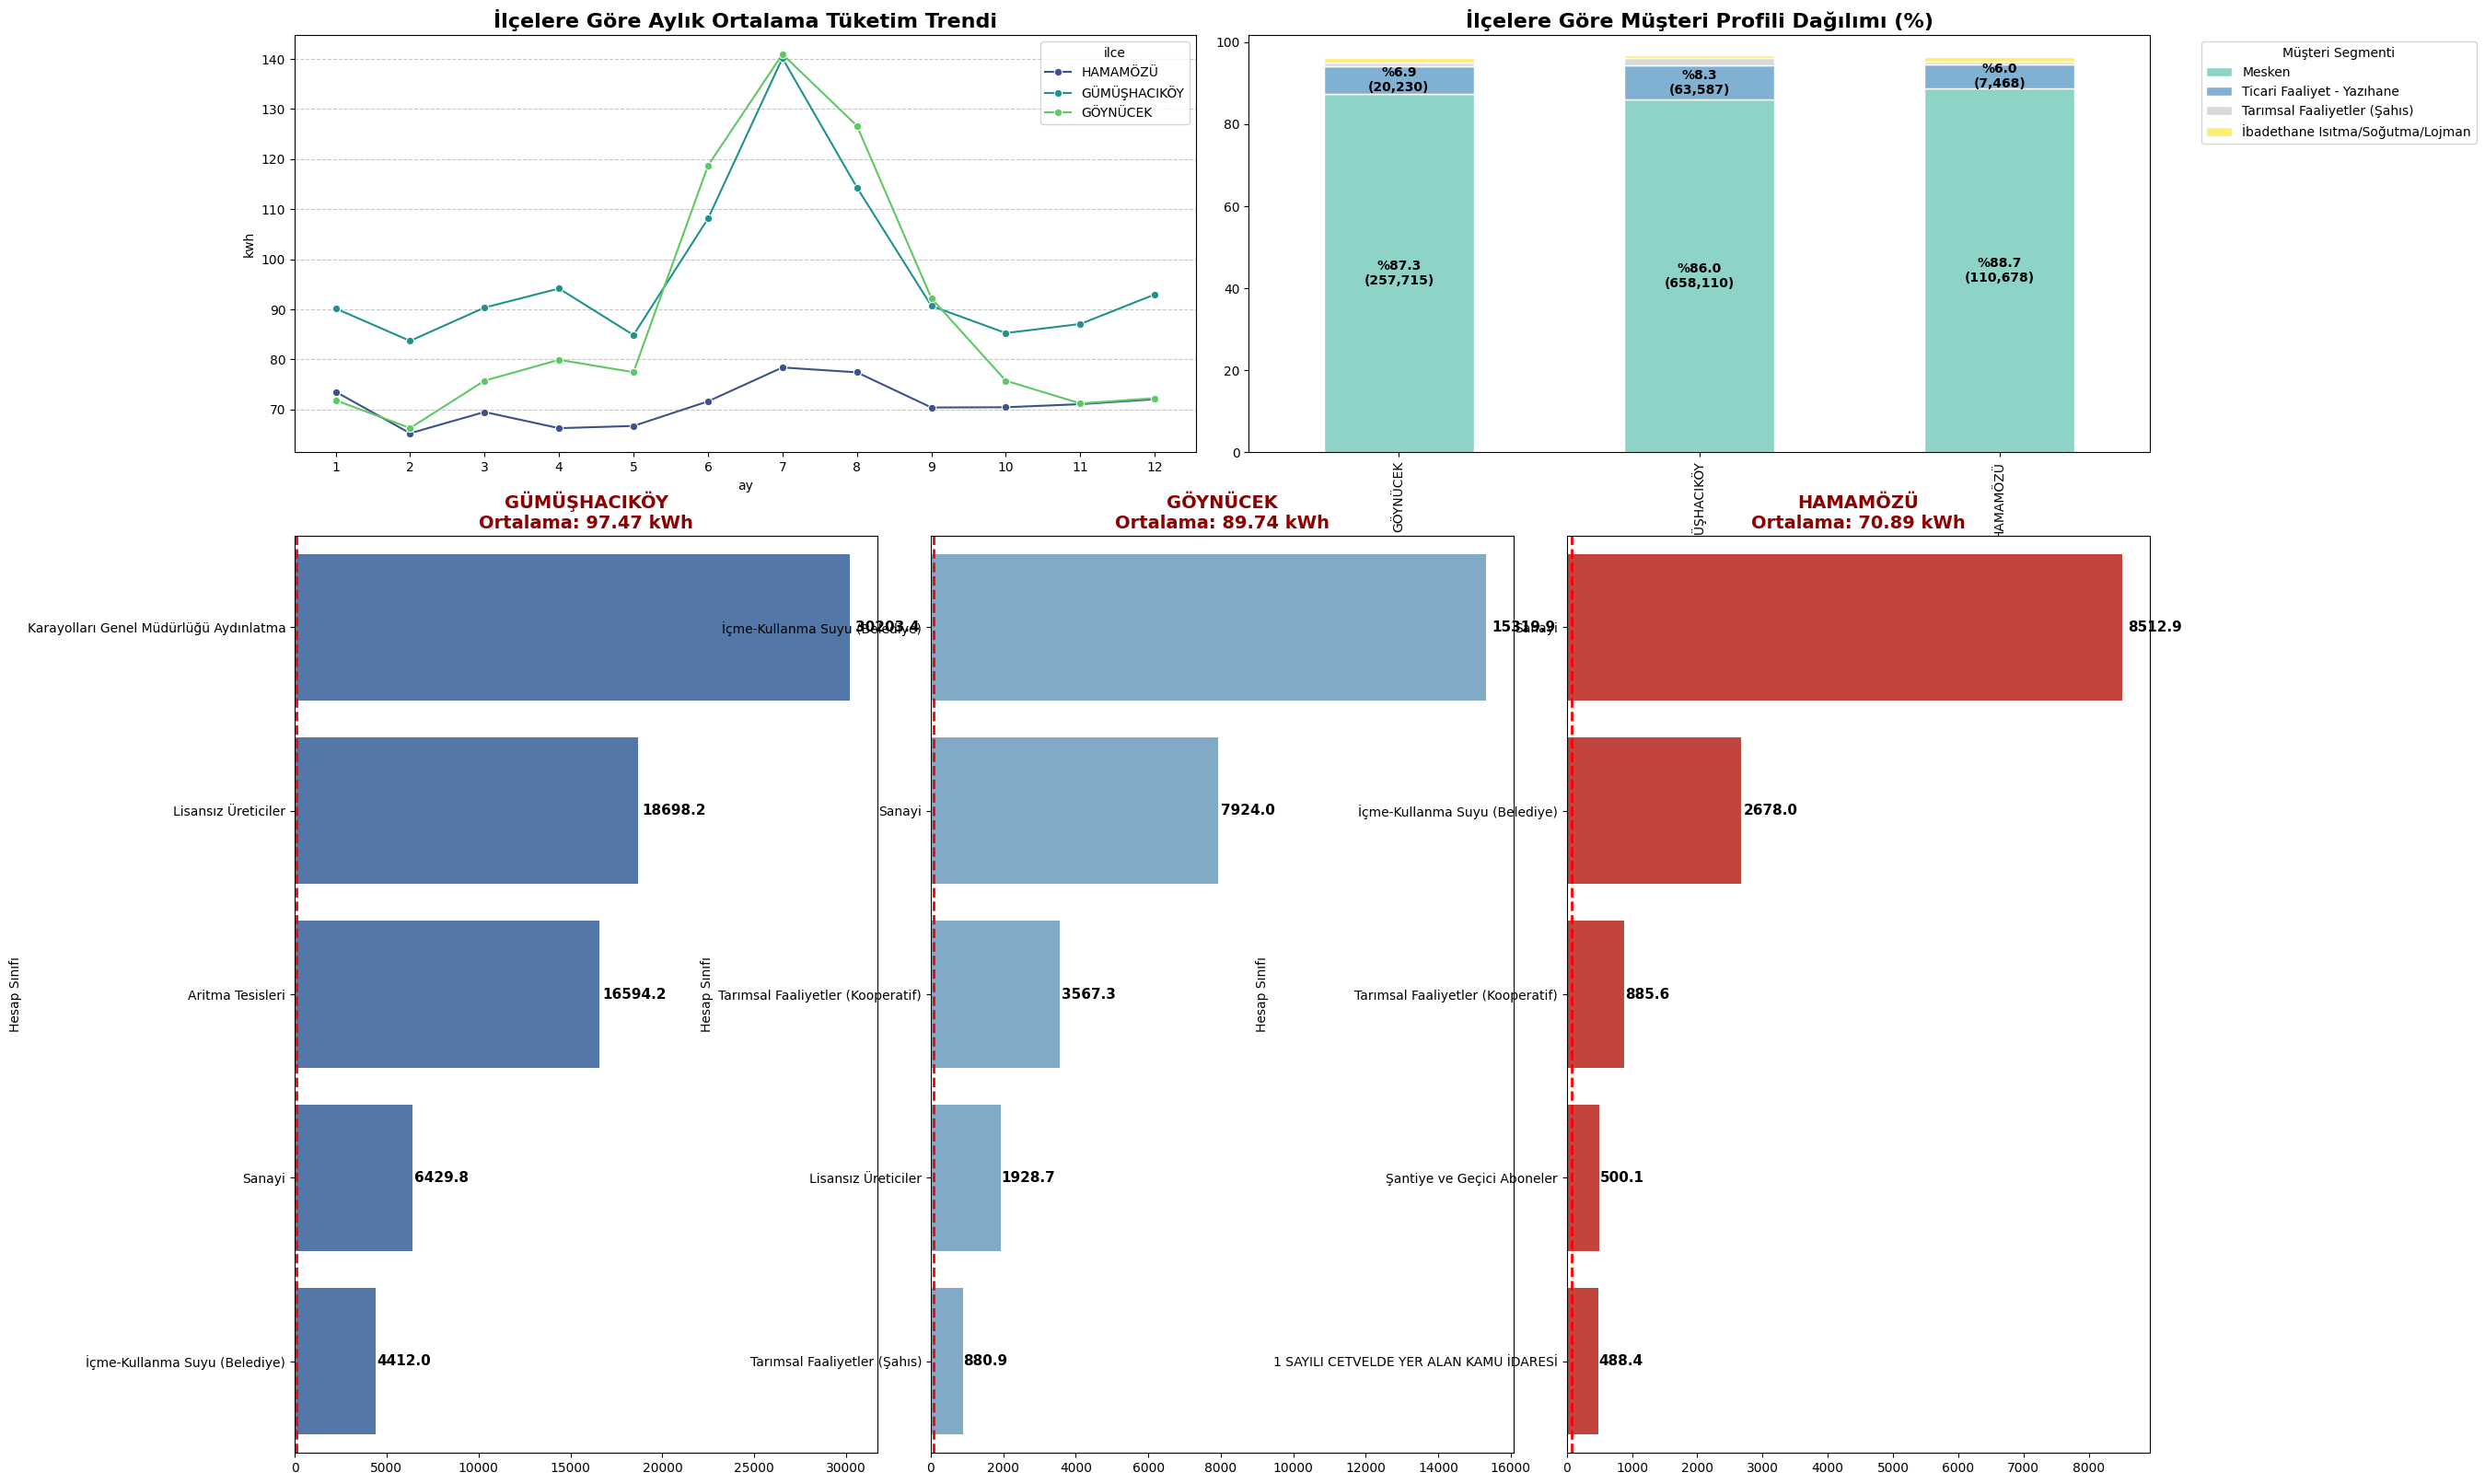

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# 1. VERİ ÖN HAZIRLIK
tahakkuk_clean['mali_yil_donem'] = pd.to_datetime(tahakkuk_clean['mali_yil_donem'])
tahakkuk_clean['ay'] = tahakkuk_clean['mali_yil_donem'].dt.month

# 2. ANALİZLER
abone_dagilimi = pd.crosstab(tahakkuk_clean['ilce'], tahakkuk_clean['Hesap Sınıfı'], normalize='index') * 100
abone_sayilari = pd.crosstab(tahakkuk_clean['ilce'], tahakkuk_clean['Hesap Sınıfı'])

# En yaygın 4 grubu alalım (Sağ üst grafik için)
top_segments = tahakkuk_clean['Hesap Sınıfı'].value_counts().nlargest(4).index
abone_dagilimi_top = abone_dagilimi[top_segments]
abone_sayilari_top = abone_sayilari[top_segments]

# --- GÖRSELLEŞTİRME ---
fig = plt.figure(figsize=(26, 20))
gs = gridspec.GridSpec(3, 6, figure=fig)

# Grafik 1: Mevsimsel Trend Analizi
ax1 = fig.add_subplot(gs[0, 0:3])
sns.lineplot(data=tahakkuk_clean, x='ay', y='kwh', hue='ilce', ax=ax1, marker='o', errorbar=None, palette='viridis')
ax1.set_title('İlçelere Göre Aylık Ortalama Tüketim Trendi', fontsize=16, fontweight='bold')
ax1.set_xticks(range(1, 13))
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Grafik 2: Abone Profili (%)
ax2 = fig.add_subplot(gs[0, 3:6])
abone_dagilimi_top.plot(kind='bar', stacked=True, ax=ax2, colormap='Set3', edgecolor='white')
ax2.set_title('İlçelere Göre Müşteri Profili Dağılımı (%)', fontsize=16, fontweight='bold')

for i, ilce in enumerate(abone_dagilimi_top.index):
    cum_height = 0
    for segment in top_segments:
        percentage = abone_dagilimi_top.loc[ilce, segment]
        count = abone_sayilari_top.loc[ilce, segment]
        if percentage > 3:
            label = f"%{percentage:.1f}\n({count:,})"
            ax2.text(i, cum_height + (percentage / 2), label, ha='center', va='center', fontsize=10, fontweight='bold')
        cum_height += percentage
ax2.legend(title='Müşteri Segmenti', bbox_to_anchor=(1.05, 1))

# Grafik 3: Her İlçe İçin Ayrı Ayrı Top 5 Tüketim + İlçe Ortalaması
ilceler = ['GÜMÜŞHACIKÖY', 'GÖYNÜCEK', 'HAMAMÖZÜ'] # Sıralı liste
colors = ['#4575b4', '#74add1', '#d73027']

for idx, ilce in enumerate(ilceler):
    ax_sub = fig.add_subplot(gs[1:, idx*2 : (idx+1)*2])
    
    # İlçeye özel veri ve genel ortalama
    ilce_data = tahakkuk_clean[tahakkuk_clean['ilce'] == ilce]
    ilce_avg = ilce_data['kwh'].mean()
    top_5 = ilce_data.groupby('Hesap Sınıfı')['kwh'].mean().sort_values(ascending=False).head(5)
    
    # Barplot
    sns.barplot(x=top_5.values, y=top_5.index, ax=ax_sub, color=colors[idx])
    ax_sub.set_title(f'{ilce}\nOrtalama: {ilce_avg:.2f} kWh', fontsize=14, fontweight='bold', color='darkred')
    
    # İlçe genel ortalamasını gösteren dikey çizgi
    ax_sub.axvline(ilce_avg, color='red', linestyle='--', linewidth=2, label=f'İlçe Ort: {ilce_avg:.1f}')
    
    # Değerleri yazdır
    for i, v in enumerate(top_5.values):
        ax_sub.text(v + (v*0.01), i, f"{v:.1f}", va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

<span style="color:darkred; font-size:18px; font-weight:bold;">
Analiz Bulguları
</span>

Hacim ve Yoğunluk: İlçelerimizdeki abonelerin yaklaşık %86-%88 gibi büyük bir çoğunluğunu Mesken grubu oluştursa da, bu grup bireysel bazda düşük tüketim yaptığı için "En Yüksek Tüketimli İlk 5 Segment" listesine girememiştir.

Ekonomik Faaliyet Farkı: Toplam tüketimdeki asıl farkı nüfus sayısından ziyade; Gümüşhacıköy ve Göynücek’te yoğunlaşan Sanayi, Arıtma Tesisleri ve Karayolları Aydınlatma gibi enerji yoğunluğu yüksek olan ticari faaliyetler belirlemektedir.

Mevsimsel Hassasiyet: Hipotezimizi destekler nitelikte; Gümüşhacıköy ve Göynücek’te Temmuz ayında görülen keskin tüketim artışı, bu bölgelerdeki tarımsal sulama ve sanayi talebinin bir sonucudur. Hamamözü'nün bu dönemde durağan kalması, bölgenin daha çok konut odaklı bir yapıya sahip olduğunu kanıtlamaktadır.

<span style="color:darkred; font-size:18px; font-weight:bold;">
Stratejik Öneriler
</span>

Segment Odaklı Yönetim: Operasyonel planlamalarda abone sayısının çokluğuna değil, enerji yükünü asıl sırtlayan stratejik sektörlere (Sanayi, Kamu, Tarım) öncelik verilmelidir.

Proaktif Altyapı Planlaması: Temmuz ayındaki yüksek talep artışını yönetebilmek adına, Gümüşhacıköy ve Göynücek bölgelerinde yaz öncesi teknik bakım ve kapasite artırım çalışmaları kritik önem taşımaktadır.

Bölgesel Yaklaşım: Hamamözü için daha standart ve verimlilik odaklı bir hizmet modeli yeterliyken; ticari hacmi yüksek olan diğer iki ilçe için "Büyük Tüketici Yönetimi" yaklaşımı benimsenmelidir.

<span style="color:#0B3D91; font-size:20px; font-weight:600;">
2.MÜŞTERİ SEGMENTASYONU
</span>

<span style="color:#008080; font-size:20px; font-weight:600;">
📌PROBLEM TANIMI
</span>

Şirket portföyündeki binlerce müşterinin enerji tüketim kapasiteleri ile ödeme alışkanlıkları arasındaki ilişkiyi anlamlandırmak temel sorundur. Sadece çok tüketenleri değil, aynı zamanda bu tüketimin bedelini düzenli ödeyenleri ve finansal risk/operasyonel yük yaratan grupları net bir şekilde ayrıştırarak, her gruba özel bir yönetim stratejisi geliştirmek hedeflenmiştir.

<span style="color:#008080; font-size:20px; font-weight:600;">
📌Hipotez
</span>

Müşteriler, tüketim miktarı (kWh) ve ödeme sadakatine göre dört belirgin gruba ayrılabilir. Yüksek tüketim yapan kurumsal/ticari abonelerin ödeme düzenlerinin daha stabil olması beklenirken; düşük tüketimli ancak ödeme takibi gerektiren grupların şirkete ek operasyonel maliyet çıkardığı öngörülmektedir.

In [22]:
# Zamanında ve geç ödeme sütunları
zamaninda_cols = ['Son Ödeme Tarihinden Önceki Tahsilat', 'Son Ödeme Tarihindeki Tahsilat']
gec_cols = ['Son Ödeme (1)', 'Son Ödeme (2)', 'Son Ödeme (3)', 'Son Ödeme (4)',
            'Son Ödeme (5)', 'Son Ödeme (6-10)', 'Son Ödeme (10-20)', 'Son Ödeme (20-30)',
            'Son Ödeme (30-60)', 'Son Ödeme (60-90)', 'Son Ödeme (90-120)',
            'Son Ödeme (120-150)', 'Son Ödeme (150-180)', 'Son Ödeme (180+)']


C:\Users\yaren\AppData\Local\Temp\ipykernel_18912\3429093307.py:59: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_segment, x='segment', y='kwh', ax=ax2, palette='viridis', ci=None)
C:\Users\yaren\AppData\Local\Temp\ipykernel_18912\3429093307.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_segment, x='segment', y='kwh', ax=ax2, palette='viridis', ci=None)


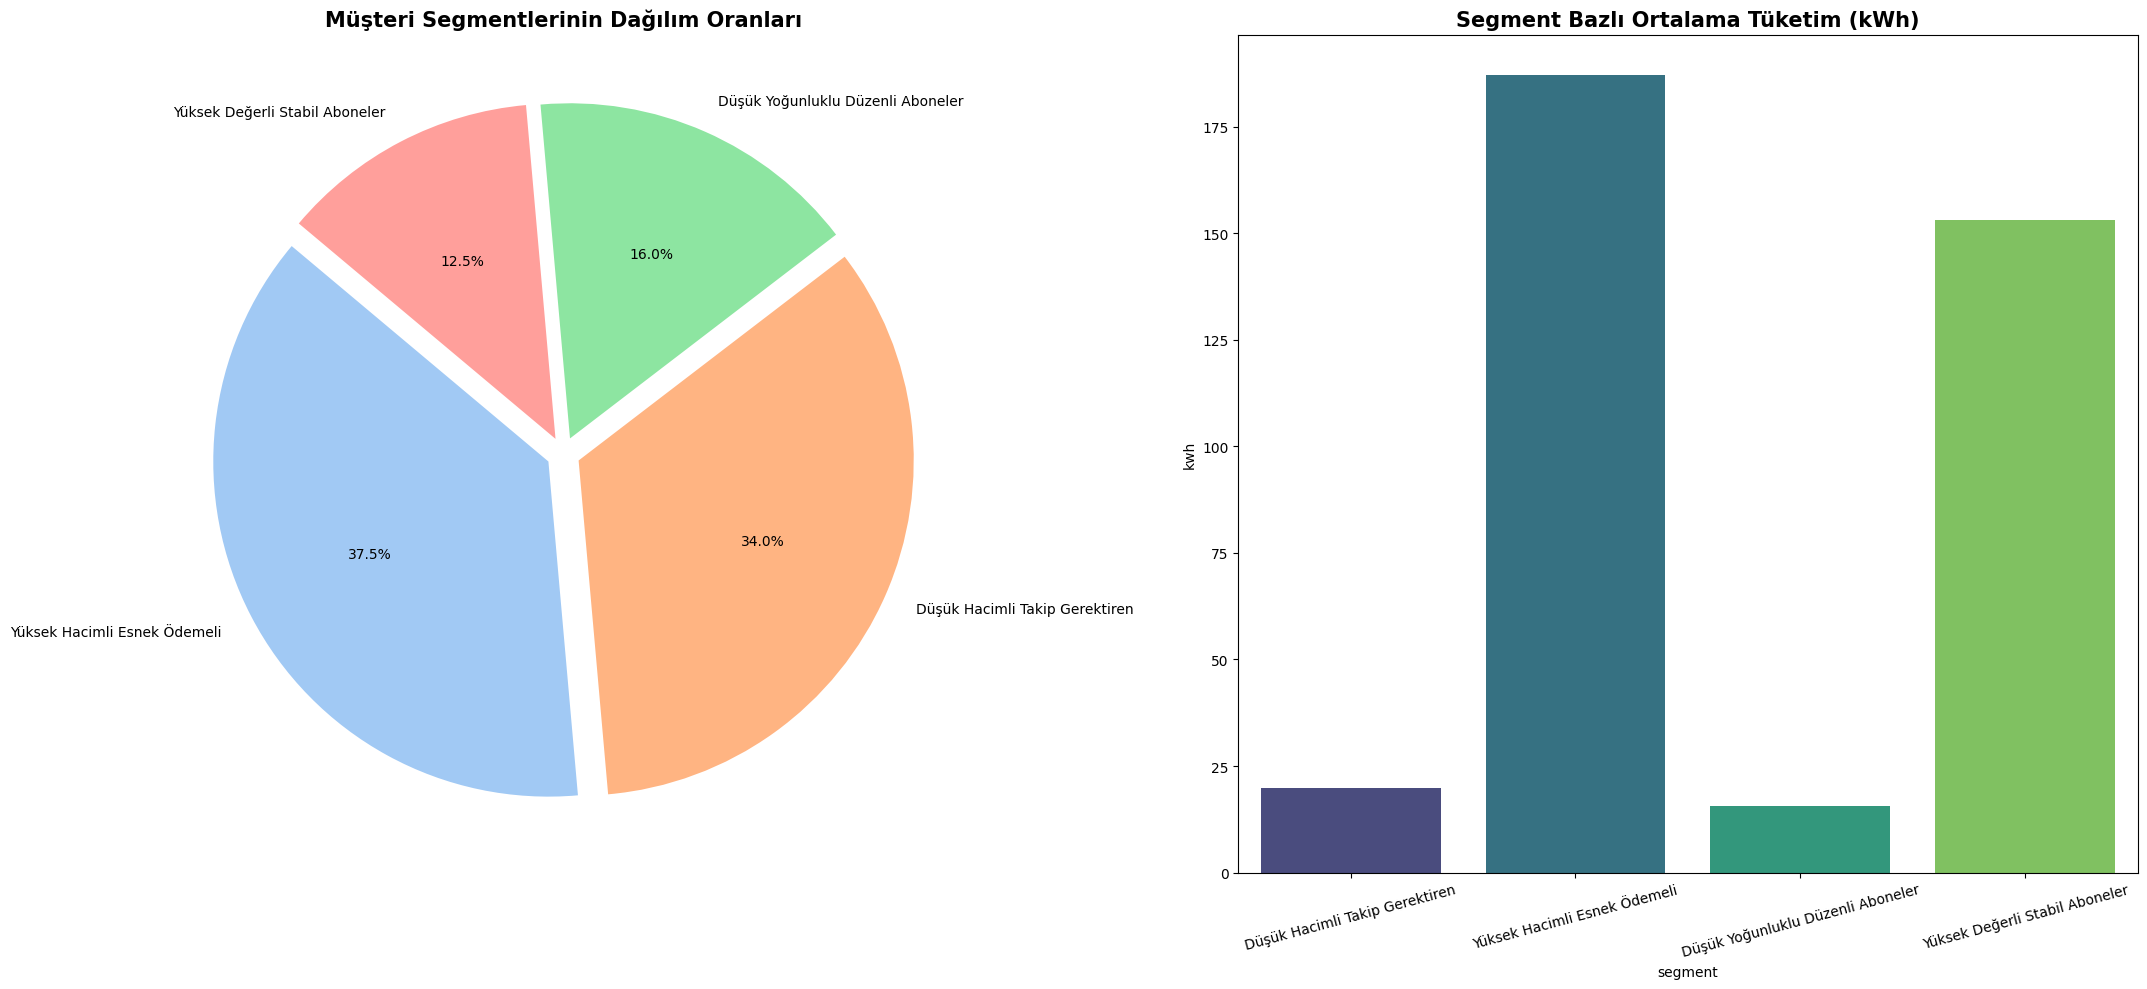

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tahsilat Verilerini Birleştirme ve Özetleme
# Her iki sayfadaki Sözleşme Hesap No sütunlarını kullanarak müşteri bazlı özet çıkaralım
# Tahsilat (Sayfa 1) - Ödeme Kanalları
customer_channels = df_tahsilat.groupby('Söz.hsp.(bağımsız)').agg({
    'Banka Tahsilatı': 'sum',
    'Nakit Tahsilat': 'sum',
    'Kredi Kartı Tahsilatı': 'sum'
}).reset_index()

# Tahsilat 1 (Sayfa 2) - Ödeme Zamanlaması
# Belirlediğimiz gecikme ve zamanında ödeme sütunlarını toplayalım
df_tahsilat1['gecikme_toplam'] = df_tahsilat1[gec_cols].sum(axis=1)
customer_timing = df_tahsilat1.groupby('Söz.hsp.(bağımsız)')['gecikme_toplam'].sum().reset_index()

# 2. Ödeme Verilerini Kendi İçinde Birleştirme
payment_full = pd.merge(customer_channels, customer_timing, on='Söz.hsp.(bağımsız)', how='outer').fillna(0)

# 3. Tüketim (Tahakkuk) ile Birleştirme
# tahakkuk_clean üzerinden müşteri bazlı ortalama kWh hesaplayalım
customer_kwh = tahakkuk_clean.groupby('sozlesme_hesap_no')['kwh'].mean().reset_index()

df_segment = pd.merge(customer_kwh, payment_full, 
                      left_on='sozlesme_hesap_no', 
                      right_on='Söz.hsp.(bağımsız)', 
                      how='inner')

# 4. Kurumsal Segmentasyon Fonksiyonu
kwh_medyan = df_segment['kwh'].median()

def segment_ata(row):
    high_kwh = row['kwh'] >= kwh_medyan
    has_delay = row['gecikme_toplam'] > 0
    
    if high_kwh and not has_delay:
        return 'Yüksek Değerli Stabil Aboneler'
    elif high_kwh and has_delay:
        return 'Yüksek Hacimli Esnek Ödemeli'
    elif not high_kwh and not has_delay:
        return 'Düşük Yoğunluklu Düzenli Aboneler'
    else:
        return 'Düşük Hacimli Takip Gerektiren'

df_segment['segment'] = df_segment.apply(segment_ata, axis=1)

# --- GÖRSELLEŞTİRME ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# Grafik 1: Segment Dağılımı (Pasta Grafiği)
segment_counts = df_segment['segment'].value_counts()
ax1.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=140, explode=[0.05]*4)
ax1.set_title('Müşteri Segmentlerinin Dağılım Oranları', fontsize=15, fontweight='bold')

# Grafik 2: Segmentlere Göre Ortalama Tüketim
sns.barplot(data=df_segment, x='segment', y='kwh', ax=ax2, palette='viridis', ci=None)
ax2.set_title('Segment Bazlı Ortalama Tüketim (kWh)', fontsize=15, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

<span style="color:darkred; font-size:18px; font-weight:bold;">
Analiz Bulguları
</span>

Portföyün Finansal Omurgası: Müşterilerin %37.5 gibi en büyük dilimini "Yüksek Hacimli Esnek Ödemeli" grubu oluşturmaktadır. Bu grup, ortalama 180+ kWh ile portföyün en yüksek enerji yoğunluğuna sahip segmentidir. Bu veri, ciromuzun büyük kısmını sırtlayan grubun aynı zamanda ödemelerde esneklik/gecikme yaşadığını kanıtlamaktadır.

Operasyonel Risk ve Takip Maliyeti: Müşterilerin %34'ü "Düşük Hacimli Takip Gerektiren" segmentinde yer almaktadır. Bu grubun ortalama tüketimi oldukça düşük (yaklaşık 20 kWh) olmasına rağmen, ödemelerindeki düzensizlik nedeniyle şirkete enerji satış kârından daha fazla "takip ve operasyon" maliyeti çıkarma riski taşımaktadır.

İdeal Müşteri Profili: Portföyün sadece %12.5'i hem yüksek tüketim yapıp hem de ödemesini hiç aksatmayan **"Yüksek Değerli Stabil Aboneler"**den oluşmaktadır. Bu grup, şirketin en kaliteli ve en az maliyetli nakit kaynağıdır.

Küçük Ama Düzenli: %16'lık "Düşük Yoğunluklu Düzenli" grup, düşük tüketimine rağmen sistemin en sorunsuz ve stabil nakit girişini temsil etmektedir.

<span style="color:darkred; font-size:18px; font-weight:bold;">
Stratejik Öneriler
</span>

Esnek Ödeme Planları: En büyük hacme sahip (%37.5) "Yüksek Hacimli Esnek Ödemeli" segmentin ödeme gecikmelerini cezalandırmak yerine, bu grubun ticari döngülerine uygun (hasat bazlı veya dönemsel) esnek faturalandırma modelleri geliştirilmelidir.

Dijital Otomasyon: %34'lük "Düşük Hacimli Takip Gerektiren" grup için manuel takip süreçleri durdurulmalı; bu gruptaki gecikmeler sadece SMS, mobil bildirim ve otomatik ödeme teşvikleri gibi düşük maliyetli dijital kanallarla yönetilmelidir.

Sadakat Programları: "Yüksek Değerli Stabil Aboneler" (%12.5) için "Öncelikli Arıza Giderme" veya "Enerji Danışmanlığı" gibi VIP hizmetler sunularak bu değerli portföyün korunması sağlanmalıdır.

Banka Tahsilatı Teşviki: Toplamda 628,933 olan banka tahsilatı sayısını artırmak adına, özellikle düzenli ödeme yapan segmentlere otomatik ödeme talimatı indirimleri sunulmalıdır.

<span style="color:#0B3D91; font-size:20px; font-weight:600;">
3.TAHSİLAT PERFORMANS ANALİZİ
</span>

<span style="color:#008080; font-size:20px; font-weight:600;">
📌PROBLEM TANIMI
</span>

Şirketimizin finansal sürdürülebilirliği, yüksek enerji tüketen abonelerin bu tüketim bedellerini ne kadar sürede ödediğine bağlıdır. Mevcut verilerde %27.2'lik bir genel geç ödeme oranı bulunmaktadır. Temel problem; hangi müşteri gruplarının hangi dönemlerde ödeme güçlüğü çektiğini belirlemek ve yaklaşık 250 bin gecikmeli kaydın yarattığı finansal yükü azaltacak veri destekli bir tahsilat stratejisi kurgulamaktır.

<span style="color:#008080; font-size:20px; font-weight:600;">
📌Hipotez
</span>

Müşterilerin ödeme performansları, enerji tüketim miktarının arttığı pik dönemlerle (mevsimsellik) ve sahip oldukları abone türüyle (Hesap Sınıfı) doğrudan ilişkilidir. Özellikle tarımsal veya ticari döngüye sahip yüksek tüketimli segmentlerin, tüketimin tavan yaptığı Temmuz ayında ödeme güçlüğü yaşayacağı ve bu durumun nakit akışında dönemsel bir "risk bölgesi" oluşturacağı öngörülmektedir.

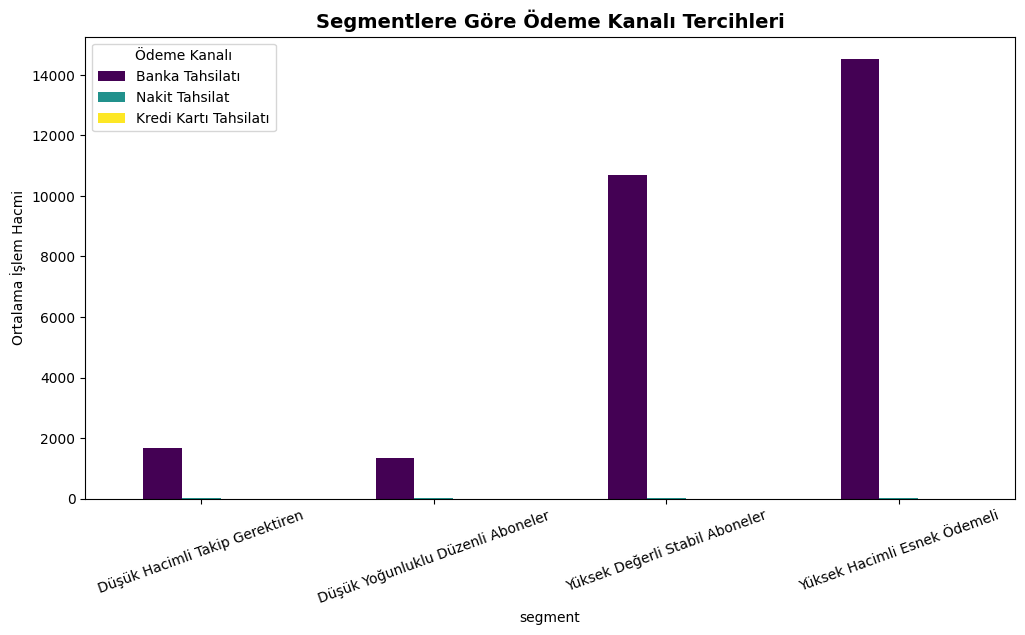

In [30]:
# Segment bazlı ortalama kanal kullanımı
kanal_risk = df_final.groupby('segment')[['Banka Tahsilatı', 'Nakit Tahsilat', 'Kredi Kartı Tahsilatı']].mean()

plt.figure(figsize=(12, 6))
kanal_risk.plot(kind='bar', ax=plt.gca(), colormap='viridis')
plt.title('Segmentlere Göre Ödeme Kanalı Tercihleri', fontsize=14, fontweight='bold')
plt.ylabel('Ortalama İşlem Hacmi')
plt.xticks(rotation=20)
plt.legend(title='Ödeme Kanalı')
plt.show()

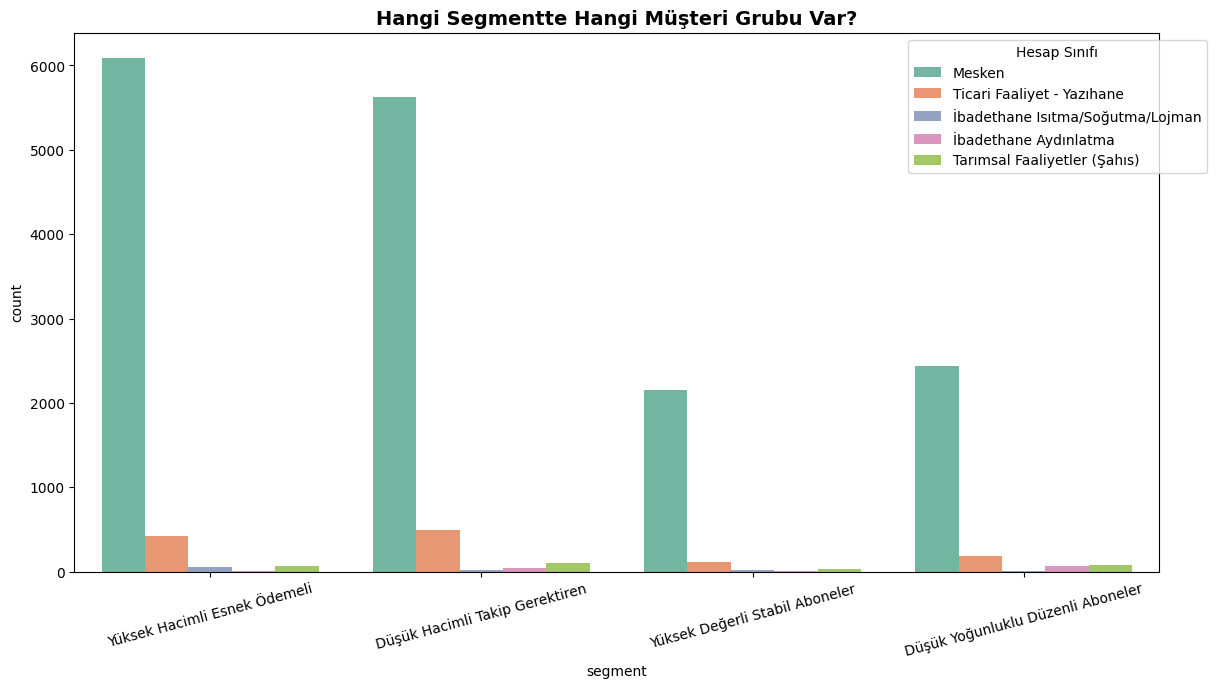

In [31]:
# Segment içindeki en yaygın 5 hesap sınıfını görelim
customer_info = tahakkuk_clean[['sozlesme_hesap_no', 'Hesap Sınıfı']].drop_duplicates(subset='sozlesme_hesap_no')
df_risk_profil = pd.merge(df_final[['sozlesme_hesap_no', 'segment']], customer_info, on='sozlesme_hesap_no')

plt.figure(figsize=(14, 7))
top_5_classes = df_risk_profil['Hesap Sınıfı'].value_counts().nlargest(5).index
sns.countplot(data=df_risk_profil[df_risk_profil['Hesap Sınıfı'].isin(top_5_classes)], 
              x='segment', hue='Hesap Sınıfı', palette='Set2')
plt.title('Hangi Segmentte Hangi Müşteri Grubu Var?', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.legend(title='Hesap Sınıfı', bbox_to_anchor=(1.05, 1))
plt.show()

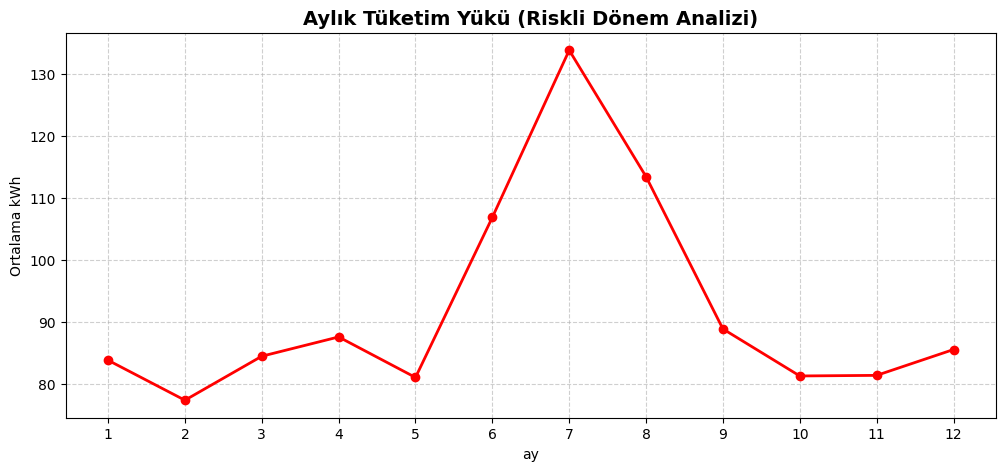

In [32]:
# Aylık ortalama tüketim trendi (Yükün arttığı aylar riskli aylardır)
tahakkuk_clean['ay'] = pd.to_datetime(tahakkuk_clean['mali_yil_donem']).dt.month
aylik_yuk = tahakkuk_clean.groupby('ay')['kwh'].mean()

plt.figure(figsize=(12, 5))
aylik_yuk.plot(kind='line', marker='o', color='red', linewidth=2)
plt.title('Aylık Tüketim Yükü (Riskli Dönem Analizi)', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13))
plt.ylabel('Ortalama kWh')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

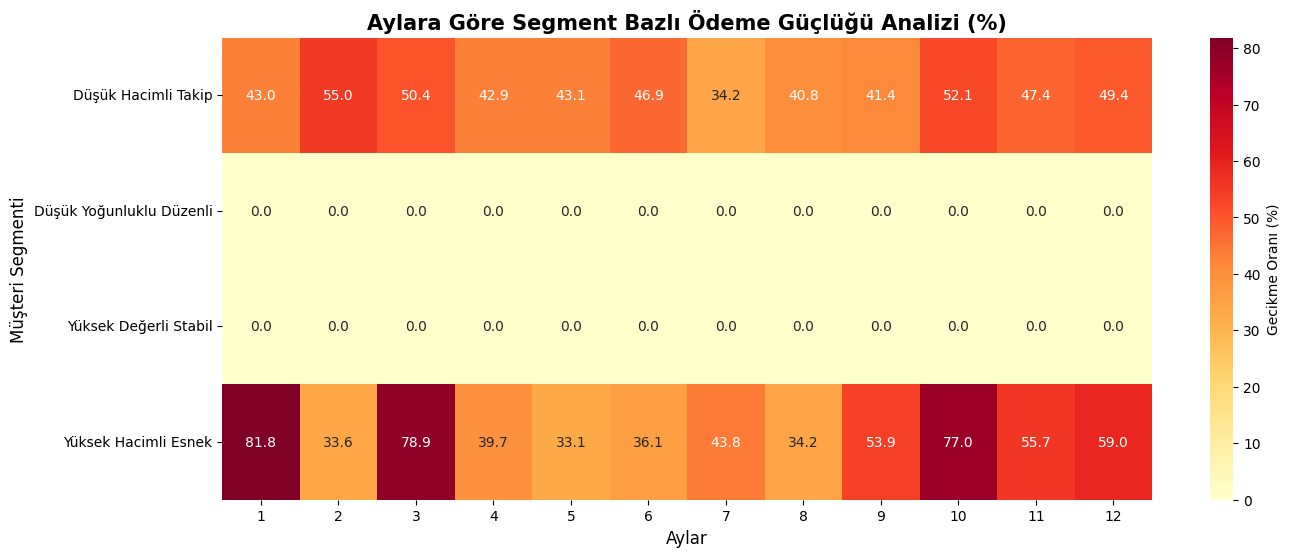

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. ADIM: VERİ HAZIRLIĞI VE HIZLI BİRLEŞTİRME ---
# Belleği yormamak için sadece gerekli sütunları gruplayarak alıyoruz
tarih_rehberi = tahakkuk_clean.groupby('sozlesme_hesap_no')['mali_yil_donem'].last().reset_index()
tarih_rehberi['ay'] = pd.to_datetime(tarih_rehberi['mali_yil_donem']).dt.month

# df_segment ve tarih bilgisini birleştirme
df_analiz = pd.merge(
    df_segment[['sozlesme_hesap_no', 'segment', 'zamaninda_toplam', 'gecikme_toplam']], 
    tarih_rehberi[['sozlesme_hesap_no', 'ay']], 
    on='sozlesme_hesap_no', 
    how='inner'
)

# --- 2. ADIM: ORAN HESAPLAMA VE TEMİZLİK ---
# Ay ve segment bazlı toplamları alalım
perf_final = df_analiz.groupby(['ay', 'segment'])[['zamaninda_toplam', 'gecikme_toplam']].sum().reset_index()

# Hatalı (negatif) veya sıfıra bölünme durumlarını engelleyerek oran hesaplama
def oran_hesapla(row):
    toplam = row['zamaninda_toplam'] + row['gecikme_toplam']
    if toplam <= 0:
        return 0
    oran = (row['gecikme_toplam'] / toplam) * 100
    return max(0, min(oran, 100)) # Oranı %0 ile %100 arasına sabitler

perf_final['gec_orani'] = perf_final.apply(oran_hesapla, axis=1)

# --- 3. ADIM: GÖRSELLEŞTİRME (ISI HARİTASI) ---
plt.figure(figsize=(15, 6))
# Veriyi ısı haritası formatına (pivot) getiriyoruz
pivot_table = perf_final.pivot(index="segment", columns="ay", values="gec_orani")

sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Gecikme Oranı (%)'})
plt.title('Aylara Göre Segment Bazlı Ödeme Güçlüğü Analizi (%)', fontsize=15, fontweight='bold')
plt.xlabel('Aylar', fontsize=12)
plt.ylabel('Müşteri Segmenti', fontsize=12)
plt.show()

Analiz Bulguları (Veri Hikayesi)
Mevsimsel Şaşırtma: Aylık tüketim yükü grafiğinde 7. ayda (Temmuz) 130-140 kWh ile zirve görülmesine rağmen, Isı Haritası bu dönemde ödeme güçlüğünün (gecikme oranının) düştüğünü göstermektedir.

Kritik Risk Dönemleri:

Yüksek Hacimli Esnek Segmenti: En büyük finansal risk, bu grubun %70 - %81.8 gecikme oranlarına ulaştığı Ocak (1.), Mart (3.) ve Ekim (10.) aylarında toplanmaktadır.

Düşük Hacimli Takip Segmenti: Bu grup, yılın genelinde %40 - %55 bandında seyreden yüksek gecikme oranıyla, şirket üzerinde kronik bir operasyonel yük oluşturmaya devam etmektedir.

Finansal Stabilite: Banka Tahsilatı üzerinden yapılan 628.933 adet işlem, şirketin ana gelir damarıdır. Ancak Ocak ve Ekim aylarındaki toplu gecikmeler, bu damardaki nakit akış hızını ciddi oranda yavaşlatmaktadır.

Abone Profili: Gecikmelerin yoğunlaştığı bu aylarda Ticari Faaliyetler ve Tarımsal Faaliyetlerin ödeme döngüleri muhtemelen ana etkendir.

Stratejik İş Önerileri
Dönemsel Tahsilat Odaklılık: Şirket kaynakları yaz aylarından ziyade, gecikmelerin "patlama" yaptığı Ocak ve Ekim aylarında tahsilat operasyonlarına (hatırlatma, kampanya vb.) kaydırılmalıdır.

Erken Uyarı Sistemi: Isı haritasında kırmızılaşan 1., 3. ve 10. aylar başlamadan 15 gün önce, Yüksek Hacimli abonelere yönelik "Vade Uzatımı" veya "Kredi Kartı Taksit" seçenekleri proaktif olarak sunulmalıdır.

Kanal Dönüşümü Teşviki: Nakit ödeme yapan (523 kayıt) ve operasyonel maliyeti yüksek olan grubun, riskli aylarda tahsilatı hızlandırmak adına tamamen dijital kanallara yönlendirilmesi sağlanmalıdır.
